Fitted k_toe:  1.7094808046673805e-05 R^2:  0.9961786651606225


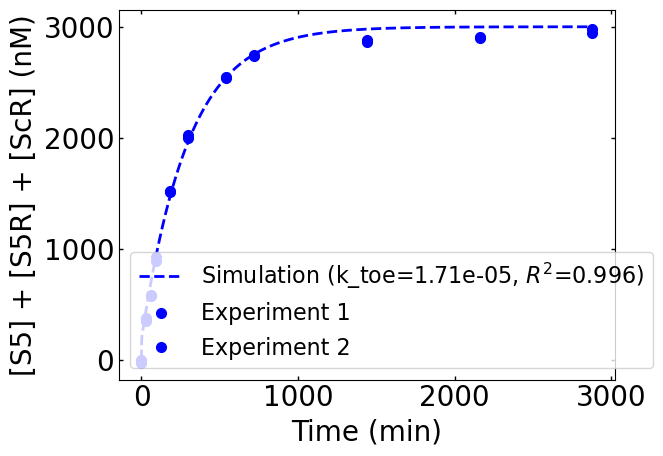

In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pandas as pd

# List of reactions for simulation
def Ribozyme_kinetics(y, t, k_hyb1, k_c1, k_l1, k_c2, k_l2,
                      k_hyb2, k_ex1, k_sca, k_hyb3, k_ex2, k_tot, k_toe):
    S, R, SR, ScR, S5R, F, SF, S3F, S3, S5 = y
    dSdt   = -k_hyb1*S*R - k_hyb2*S*F - k_ex2*S5R*S - k_tot*S*ScR
    dRdt   = -k_hyb1*S*R - k_ex1*SF*R - k_hyb3*S5*R
    dSRdt  = k_hyb1*S*R - k_c1*0.57*SR + k_l1*0.57*ScR - k_c2*0.43*SR + k_l2*0.43*ScR + \
             k_ex1*SF*R + k_ex2*S5R*S + k_toe*S5R*SF
    dScRdt = k_c1*0.57*SR - k_l1*0.57*ScR + k_c2*0.43*SR - k_l2*0.43*ScR - k_sca*ScR*F
    dS5Rdt = k_sca*ScR*F + k_hyb3*S5*R - k_ex2*S5R*S - k_toe*S5R*SF
    dS5dt  = -k_hyb3*S5*R + k_ex2*S5R*S + k_toe*S5R*SF + k_tot*S*ScR
    dFdt   = -k_hyb2*S*F + k_ex1*SF*R - k_sca*ScR*F + k_toe*S5R*SF
    dSFdt  = k_hyb2*S*F - k_ex1*SF*R - k_toe*S5R*SF
    dS3Fdt = k_sca*ScR*F
    dS3dt  = k_tot*S*ScR
    return [dSdt, dRdt, dSRdt, dScRdt, dS5Rdt, dFdt, dSFdt, dS3Fdt, dS3dt, dS5dt]
    
# Initial concentrations (nM)
S0   = 3000  # Substrate
R0   = 200   # Ribozyme
SR0  = 0     # Substrate-ribozyme complex
ScR0 = 0     # Cleaved product-ribozyme complex
S5R0 = 0     # S5R complex
SF0  = 0     # Sub-Sca complex
S3F0 = 0     # 3' end product-Sca complex
S30  = 0     # 3' end product
S50  = 0     # 5' end product

# Fixed rate constants (converted to per minute units)
k_hyb1 = 3.5e6/1e9 * 60   # hybridization rate constant (S + R)
k_c1   = 2.59            # cleavage rate (min^-1)
k_l1   = 0.052           # ligation rate (min^-1)
k_c2   = 0.14            # second cleavage rate (min^-1)
k_l2   = 0.0028          # second ligation rate (min^-1)
k_hyb2 = 1e6/1e9 * 60     # hybridization rate constant 2 (S + F)
k_ex1  = 1e6/1e9 * 60     # exchange reaction: SF + R -> SR + F
k_sca  = 5e4/1e9 * 60     # scavenging rate constant
k_hyb3 = 1e6/1e9 * 60     # hybridization rate constant 3 (S5 + R)
k_ex2  = 1e6/1e9 * 60     # exchange reaction: S5R + S -> SR + S5
k_tot  = 6.8/1e9 * 60       # total replacement rate
initial_k_toe = 3e2/1e9 * 60  # toe

# Simulation time (minutes)
t_sim = np.linspace(0, 2880, 2881)

# Scavenger initial concentration (F0)
F0 = 20000

# Pack initial conditions vector
y0 = [S0, R0, SR0, ScR0, S5R0, F0, SF0, S3F0, S30, S50]

# Call experimental results
exp_data = pd.read_excel('20250219_KBH With Scavenger, HHR_raw data.xlsx')
t_exp = exp_data['Time (min)'].values
avg_exp = exp_data[['Experiment 1', 'Experiment 2']].mean(axis=1).values

# Perform simulation
def simulate_model(k_toe_value, t=t_sim):
    """Run the ODE simulation for a given k_toe and return the summed output."""
    params = (k_hyb1, k_c1, k_l1, k_c2, k_l2,
              k_hyb2, k_ex1, k_sca, k_hyb3, k_ex2, k_tot, k_toe_value)
    Results = odeint(Ribozyme_kinetics, y0, t, args=params)
    # Extract outputs:
    S5output  = Results[:, -1]      # S50
    S5Routput = Results[:, -6]       # S5R (10 - 6 = index 4)
    ScRoutput = Results[:, -7]       # ScR (10 - 7 = index 3)
    Output_Summation = S5output + S5Routput + ScRoutput
    return Output_Summation

# Residual function for optimization
def residuals(params):
    """Compute the difference between simulation and experimental data."""
    k_toe_val = params[0]
    sim_output = simulate_model(k_toe_val, t_sim)
    sim_interp = np.interp(t_exp, t_sim, sim_output)
    return sim_interp - avg_exp
    
initial_params = [initial_k_toe]
result = least_squares(residuals, initial_params)
fit_k_toe = result.x[0]

# Plot simulation and experiments
Output_Summation = simulate_model(fit_k_toe, t_sim)# Run simulation with best-fit k_toe
Output_Summation_interp = np.interp(t_exp, t_sim, Output_Summation)

# Calculate R^2
SS_res = np.sum((avg_exp - Output_Summation_interp) ** 2)
SS_tot = np.sum((avg_exp - np.mean(avg_exp)) ** 2)
R2 = 1 - SS_res/SS_tot

print(f"Fitted k_toe: ", fit_k_toe, f"R^2: ", R2)

lw = 2
fs = 20

fig, ax1 = plt.subplots()
# Plot simulation result using best-fit k_toe
ax1.plot(t_sim, Output_Summation, label=f'Simulation (k_toe={fit_k_toe:.2e}, $R^2$={R2:.3f})',
         color='blue', linestyle='--', linewidth=lw)
# Plot experimental data (using Experiment 1 and Experiment 2)
ax1.plot(exp_data['Time (min)'], exp_data['Experiment 1'], marker='o', 
         label='Experiment 1', color=(0, 0, 1), linestyle='None', markersize=7)
ax1.plot(exp_data['Time (min)'], exp_data['Experiment 2'], marker='o', 
         label='Experiment 2', color=(0, 0, 1), linestyle='None', markersize=7)
# Optional shading if desired to show min/max values based on experimental trials
# ax1.fill_between(exp_data['Time (min)'], exp_data['Minimum'],  exp_data['Maximum'], color=(0,0,1), alpha=0, linewidth = 0, interpolate=True)

# Customize the plot
ax1.set_xlabel('Time (min)', fontsize=fs)
ax1.set_ylabel('[S5] + [S5R] + [ScR] (nM)', fontsize=fs)
ax1.tick_params(axis='both', which='both', labelsize=fs)
ax1.xaxis.set_tick_params(which='both', size=3, width=1, direction='in', top='on')
ax1.yaxis.set_tick_params(which='both', size=3, width=1, direction='in', right='on')
ax1.legend(fontsize=fs-4)
plt.show()
